# Constant Velocity Scenario Comparison

This notebook combines the classical EKF experiment and trained neural workflows in one place. It compares `CEKF`, `DEKF`, `DKN`, and optional `GNN-RNN` checkpoints on the same constant-velocity distance/angle tracking scenario.

In [1]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
import utils.BaselineModels as baseline_models_module
importlib.reload(constant_velocity_scenario_module)
importlib.reload(baseline_models_module)

from utils.BaselineModels import GnnRnnLightning
from utils.ClassicDistributedKalman import (
    centralized_extended_kalman_filter,
    diffusion_extended_kalman_filter_parallel_edge,
)
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    build_graph_data_for_dkn,
    create_distance_based_graph,
    generate_measurements,
    generate_node_positions,
    generate_trajectory,
    list_experiments,
    load_config,
    load_experiment_config,
    plot_graph,
    plot_tracking_results,
    plot_trajectory_and_nodes,
    seed_everything,
)
from utils.DistributedKalmanNet import GraphKalmanProcess


## Experiment Selection

List available experiments under `save_root` and pick which one to load.  The experiment's `experiment_config_<n>.json` drives the entire comparison.

In [2]:
base_config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
base_config = load_config(base_config_path)
save_root = REPO_ROOT / base_config["save_root"]

experiments = list_experiments(save_root)
if not experiments:
    raise RuntimeError(f"No experiment_* folders found under {save_root}")

print("Available experiments:")
for i, exp in enumerate(experiments, start=1):
    tag = ""
    description = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        exp_title = ecfg.get("title", "")
        title_str = f' — "{exp_title}"' if exp_title else ""
        tag = f"  (train_T={ecfg.get('train_time_steps','?')}, lr={ecfg.get('learning_rate','?')}){title_str}"
        description = ecfg.get("description", "")
    print(f"  [{i}] {exp.name}{tag}")
    if description:
        print(f"      {description}")


Available experiments:
  [1] experiment_1  (train_T=20, lr=0.001)
      baseline with lr=1e-3 and 20 time steps, 10000 train sims, only 0.25 noise
  [2] experiment_2  (train_T=20, lr=0.001)
      baseline with lr=1e-3 and 20 time steps, 20000 train sims, only 0.25 noise
  [3] experiment_3  (train_T=20, lr=0.001)
      baseline with lr=1e-3 and 20 time steps, 20000 train sims, all noises (0.25 - 4.0)
  [4] experiment_4  (train_T=50, lr=0.001)
      lr=1e-3 and 50 time steps, 20000 train sims, all noises (0.25 - 4.0)
  [5] experiment_5  (train_T=30, lr=0.001)
      lr=1e-3 and 30 time steps, 20000 train sims, only 0.25 noise, position_only_loss=true
  [6] experiment_6  (train_T=30, lr=0.001)
      lr=1e-3 and 30 time steps, 20000 train sims, position_only_loss=true, all noise levels
  [7] experiment_7  (train_T=30, lr=0.001)
      lr=1e-3 and 10,20,30 time steps, 20000 train sims, accumulated training
  [8] experiment_8  (train_T=20, lr=0.001)
      20 nodes basline
  [9] experiment_9  (

Loaded experiment: experiment_12
seed                                                                       42
state_dimension                                                             4
x0                                                             [0, 50, 0, 50]
time_delta                                                               0.08
process_noise_std                                                         2.0
p0_scale                                                                 10.0
measurement_noise_values                                                [1.0]
use_dt_mismatch                                                         False
dt_mismatch_values                                                      [1.0]
num_nodes                                                                  10
graph_seed                                                                 42
k_neighbors                                                                 5
node_positions              [[7

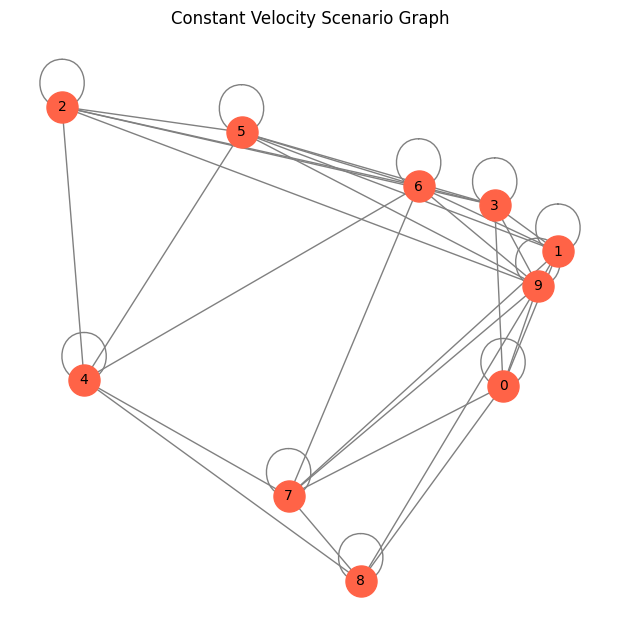

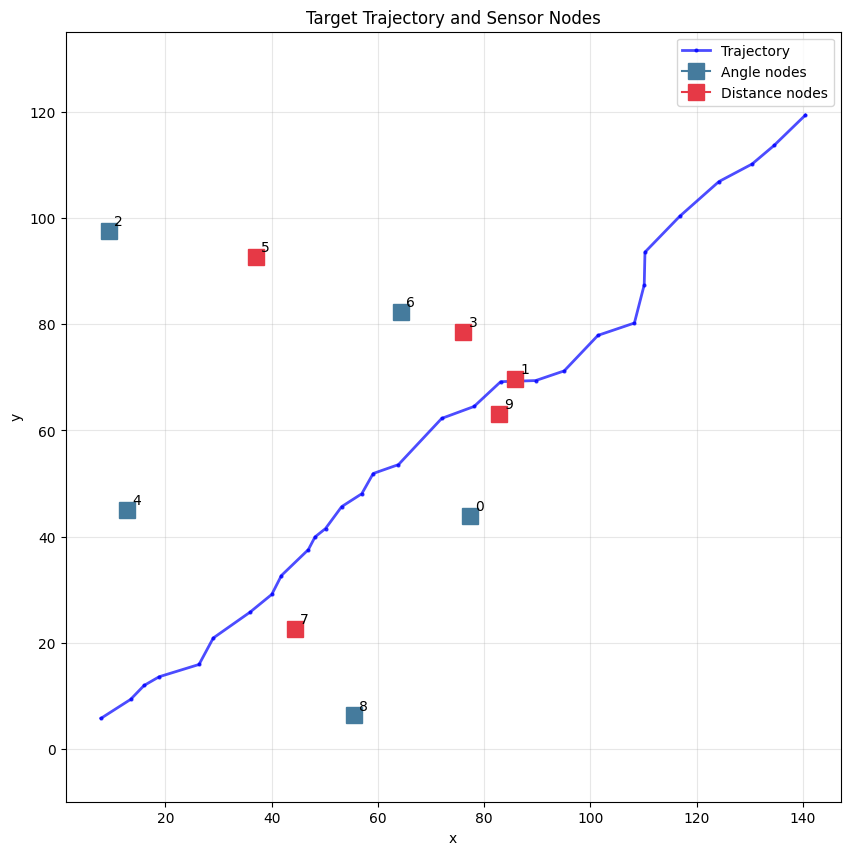

In [3]:
EXPERIMENT = 12 # ← set this to the number printed above, then run

experiment_dir = experiments[EXPERIMENT - 1]
config_val = load_experiment_config(experiment_dir)
print(f"Loaded experiment: {experiment_dir.name}")
print(pd.Series(config_val))

seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
use_dt_mismatch = config_val.get("use_dt_mismatch", False)
dt_mismatch_values = config_val.get("dt_mismatch_values", [1.0])
default_dkn_dt_ratio = min(dt_mismatch_values, key=lambda ratio: abs(float(ratio) - 1.0)) if use_dt_mismatch else None

state_dimension = config_val["state_dimension"]
x_init = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
p0 = np.eye(state_dimension) * config_val["p0_scale"]

train_time_steps = config_val["train_time_steps"]
test_time_steps = config_val.get("test_time_steps", train_time_steps)
num_time_steps = test_time_steps
num_trials = config_val["num_trials"]
process_noise_std = config_val["process_noise_std"]
time_delta = config_val["time_delta"]
measurement_noise_values = config_val["measurement_noise_values"]
node_positions = np.array(config_val["node_positions"], dtype=float)
f_system = ConstantVelocityModel(time_delta)
f_system_dkn = ConstantVelocityModel(time_delta * float(default_dkn_dt_ratio)) if use_dt_mismatch else f_system
h_system = DistanceAngleObservation(node_positions)
node_types = h_system.node_classification[:, 0].numpy().astype(int)

adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
j_matrix = np.array(adjacency_matrix, dtype=float, copy=True)
np.fill_diagonal(j_matrix, 1.0)

# Match checkpoint names from DKN_training.py, including optional dt-mismatch runs.
def dkn_run_name(r_noise, dt_ratio=None):
    if use_dt_mismatch:
        ratio = default_dkn_dt_ratio if dt_ratio is None else dt_ratio
        return f"r={r_noise}_dtx{ratio}"
    return f"r={r_noise}"

def dkn_model_path(r_noise, dt_ratio=None, base_dir=experiment_dir):
    return base_dir / "DKN" / f"{dkn_run_name(r_noise, dt_ratio)}.pth"

def gnn_rnn_run_name(r_noise):
    return f"r={r_noise}"

def gnn_rnn_model_path(r_noise, base_dir=experiment_dir):
    return base_dir / "GNN_RNN" / f"{gnn_rnn_run_name(r_noise)}.pth"

def build_gnn_rnn_model(config):
    return GnnRnnLightning(
        input_dim=1,
        type_num=2,
        hidden_dim=config.get("gnn_rnn_hidden_dim", config["hidden_dim"]),
        output_dim=state_dimension,
        lr=config.get("gnn_rnn_learning_rate", config["learning_rate"]),
    )

def predict_gnn_rnn(model, graph_data, graph_h_system):
    node_types = graph_h_system.node_classification.to(dtype=torch.long)
    with torch.no_grad():
        return model(graph_data.x, node_types, graph_data.edge_index).cpu().numpy().mean(axis=0)

def clean_measurements_for_trajectory(graph_h_system, trajectory):
    clean = np.zeros((graph_h_system.num_nodes, 1, trajectory.shape[0]))
    for k in range(trajectory.shape[0]):
        x_k = trajectory[k].numpy() if isinstance(trajectory[k], torch.Tensor) else trajectory[k]
        clean[:, 0, k] = graph_h_system.func(x_k)[:, 0]
    if hasattr(graph_h_system, "wrap_measurements"):
        clean = graph_h_system.wrap_measurements(clean, sensor_axis=0)
    return clean

def measurement_snr_db(graph_h_system, trajectory, measurements, eps=1e-12):
    clean = clean_measurements_for_trajectory(graph_h_system, trajectory)
    noise = measurements - clean
    if hasattr(graph_h_system, "wrap_innovation"):
        noise = graph_h_system.wrap_innovation(noise, sensor_axis=0)
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    return 10 * np.log10((signal_power + eps) / (noise_power + eps))

dkn_dir = experiment_dir / "DKN"
gnn_rnn_dir = experiment_dir / "GNN_RNN"
available_noise_values = [r for r in measurement_noise_values if dkn_model_path(r).exists()]
missing_noise_values = [r for r in measurement_noise_values if r not in available_noise_values]
if missing_noise_values:
    print(f"Warning: missing DKN checkpoints for r={missing_noise_values} in {dkn_dir} - skipping.")
if not available_noise_values:
    raise RuntimeError(f"No DKN checkpoints found in {dkn_dir}")

gnn_rnn_available_noise_values = [r for r in available_noise_values if gnn_rnn_model_path(r).exists()]
missing_gnn_rnn_noise_values = [r for r in available_noise_values if r not in gnn_rnn_available_noise_values]
if missing_gnn_rnn_noise_values:
    print(f"Warning: missing GNN-RNN checkpoints for r={missing_gnn_rnn_noise_values} in {gnn_rnn_dir} - omitting GNN-RNN for those rows.")
use_gnn_rnn = len(gnn_rnn_available_noise_values) > 0
measurement_noise_values = available_noise_values

plot_dir = experiment_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

def get_trial_data(r_noise):
    trajectory = generate_trajectory(f_system, x_init, num_time_steps, process_noise_std)
    measurements = generate_measurements(h_system, trajectory, r_noise)
    return trajectory, measurements

print(f"\nTrain nodes:      {num_nodes}")
print(f"Train time steps: {train_time_steps}")
print(f"Test time steps:  {test_time_steps}")
if use_dt_mismatch:
    print(f"DKN checkpoint dt ratio for non-mismatch sections: {default_dkn_dt_ratio}")
plot_graph(adjacency_matrix, node_positions, title="Constant Velocity Scenario Graph")
plot_trajectory_and_nodes(node_positions, node_types, generate_trajectory(f_system, x_init, num_time_steps, process_noise_std))


## Single-Trial Comparison

Run one scenario and visualize the trajectory estimates from `CEKF`, `DEKF`, `DKN`, and optional `GNN-RNN` on exactly the same measurements.

/Users/inega/Python/kalmanet2/distributedKNET/utils/ConstantVelocityScenario.py:456: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trajectory_tensor = torch.tensor(trajectory, dtype=torch.float32)


Saved tracking plot: /Users/inega/Python/kalmanet2/distributedKNET/models/itay/experiment_12/plots/r=1.0_tracking_comparison.png


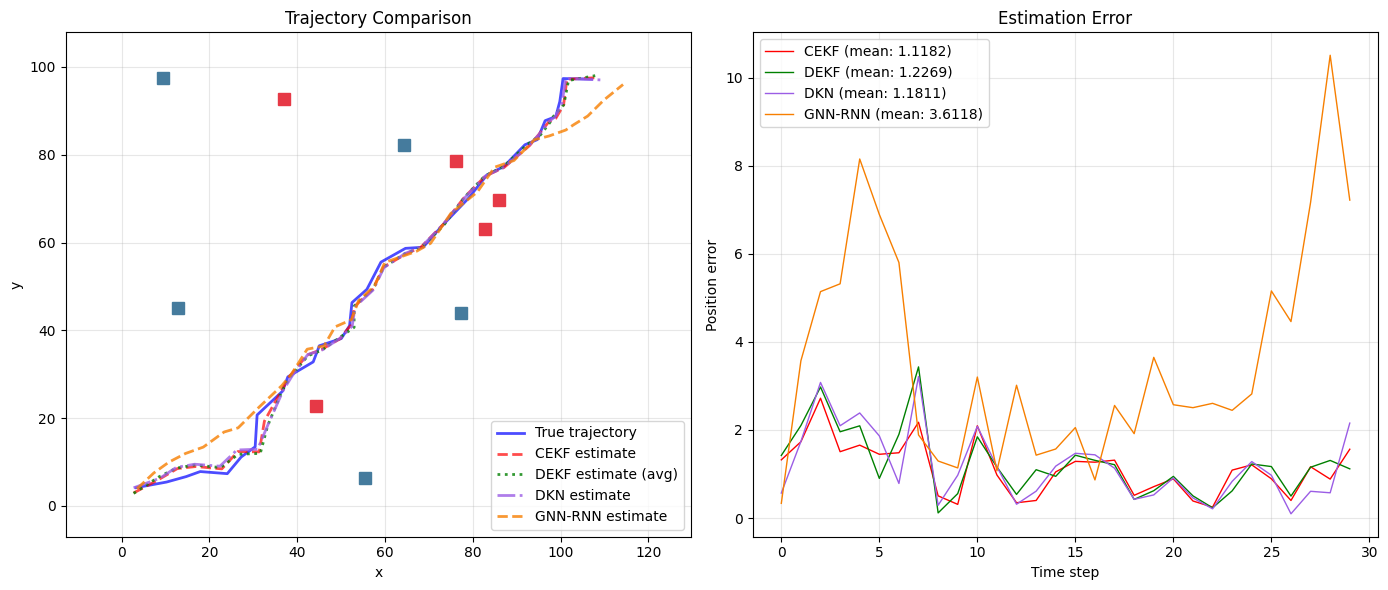

In [4]:
r_demo = 0.25 if 0.25 in measurement_noise_values else measurement_noise_values[0]
trajectory, measurements = get_trial_data(r_demo)

x_hat_cekf = centralized_extended_kalman_filter(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    j_matrix=j_matrix,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
kalman_process = GraphKalmanProcess(
    f_system_dkn,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    r_array=r_demo,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
run_name_demo = dkn_run_name(r_demo)
example_model_path = dkn_model_path(r_demo)
kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
kalman_process.eval()
with torch.no_grad():
    x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

x_hat_gnn_rnn = None
if gnn_rnn_model_path(r_demo).exists():
    gnn_rnn_process = build_gnn_rnn_model(config_val)
    gnn_rnn_process.load_state_dict(torch.load(gnn_rnn_model_path(r_demo), map_location="cpu"))
    gnn_rnn_process.eval()
    x_hat_gnn_rnn = predict_gnn_rnn(gnn_rnn_process, graph_data, h_system)

demo_tracking_plot_path = plot_dir / f"{run_name_demo}_tracking_comparison.png"
plot_tracking_results(
    trajectory,
    x_hat_cekf,
    x_hat_dekf=x_hat_dekf,
    x_hat_dkn=x_hat_dkn,
    x_hat_gnn_rnn=x_hat_gnn_rnn,
    node_positions=node_positions,
    node_types=node_types,
    save_path=demo_tracking_plot_path,
)


## Monte Carlo Study

For each measurement noise level, evaluate `CEKF`, `DEKF`, the matching trained `DKN`, and optional `GNN-RNN` checkpoints on the same set of randomly generated trajectories. The results include both noise-vs-error and empirical SNR-vs-error plots.

In [5]:
avg_snr_db = []
avg_error_cekf = []
avg_error_dekf = []
avg_error_dkn = []
avg_error_gnn_rnn = []

for r_noise in measurement_noise_values:
    r_array = r_noise * np.ones(num_nodes)
    run_name = dkn_run_name(r_noise)
    example_model_path = dkn_model_path(r_noise)

    kalman_process = GraphKalmanProcess(
        f_system,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=config_val["hidden_dim"],
        lr=config_val["learning_rate"],
        r_array=r_noise,
        learn_edge_kalman=config_val["learn_edge_kalman"],
        x0_scale=x_init,
    )
    kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
    kalman_process.eval()

    gnn_rnn_process = None
    if gnn_rnn_model_path(r_noise).exists():
        gnn_rnn_process = build_gnn_rnn_model(config_val)
        gnn_rnn_process.load_state_dict(torch.load(gnn_rnn_model_path(r_noise), map_location="cpu"))
        gnn_rnn_process.eval()

    trial_snr_db = []
    trial_errors_cekf = []
    trial_errors_dekf = []
    trial_errors_dkn = []
    trial_errors_gnn_rnn = []

    for _ in tqdm(range(num_trials), desc=f"r={r_noise}"):
        trajectory, measurements = get_trial_data(r_noise)
        trial_snr_db.append(measurement_snr_db(h_system, trajectory, measurements))

        x_hat_cekf = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )
        x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)
        x_hat_gnn_rnn = predict_gnn_rnn(gnn_rnn_process, graph_data, h_system) if gnn_rnn_process is not None else None

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf[:, 0, 0]
        y_cekf = x_hat_cekf[:, 2, 0]
        trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn[:, 0]) ** 2 + (y_true - x_hat_dkn[:, 2]) ** 2).mean())
        if x_hat_gnn_rnn is not None:
            trial_errors_gnn_rnn.append(np.sqrt((x_true - x_hat_gnn_rnn[:, 0]) ** 2 + (y_true - x_hat_gnn_rnn[:, 2]) ** 2).mean())

    avg_snr_db.append(np.mean(trial_snr_db))
    avg_error_cekf.append(np.mean(trial_errors_cekf))
    avg_error_dekf.append(np.mean(trial_errors_dekf))
    avg_error_dkn.append(np.mean(trial_errors_dkn))
    avg_error_gnn_rnn.append(np.mean(trial_errors_gnn_rnn) if trial_errors_gnn_rnn else np.nan)

results_df = pd.DataFrame(
    {
        "measurement_noise": measurement_noise_values,
        "snr_db": avg_snr_db,
        "CEKF": avg_error_cekf,
        "DEKF": avg_error_dekf,
        "DKN": avg_error_dkn,
        "GNN-RNN": avg_error_gnn_rnn,
    }
)
results_df


r=1.0: 100%|██████████| 50/50 [00:02<00:00, 22.33it/s]


,measurement_noise,snr_db,CEKF,DEKF,DKN,GNN-RNN
0,1.0,32.480327,0.992244,1.090224,1.050955,3.668176


Saved summary plot: /Users/inega/Python/kalmanet2/distributedKNET/models/itay/experiment_12/plots/const_vel_scenario_summary_trials=50_T=30.png


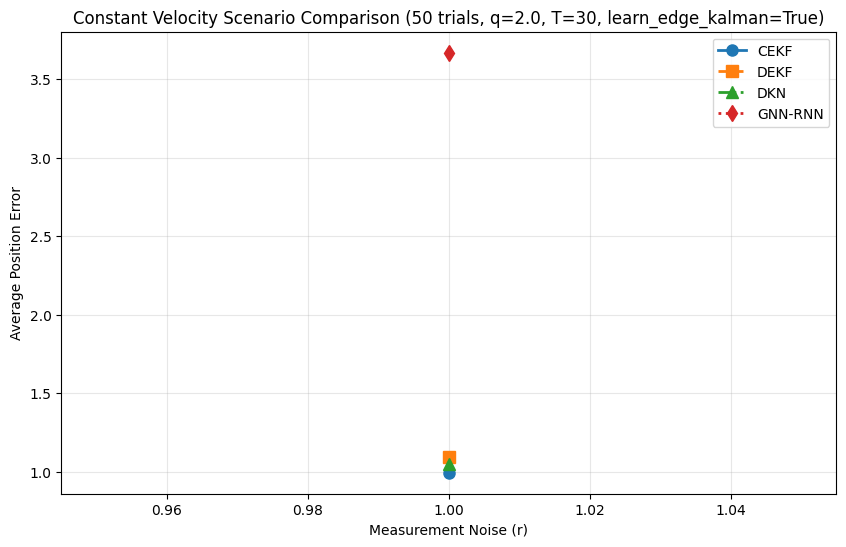

Saved SNR summary plot: /Users/inega/Python/kalmanet2/distributedKNET/models/itay/experiment_12/plots/const_vel_scenario_snr_vs_error_trials=50_T=30.png


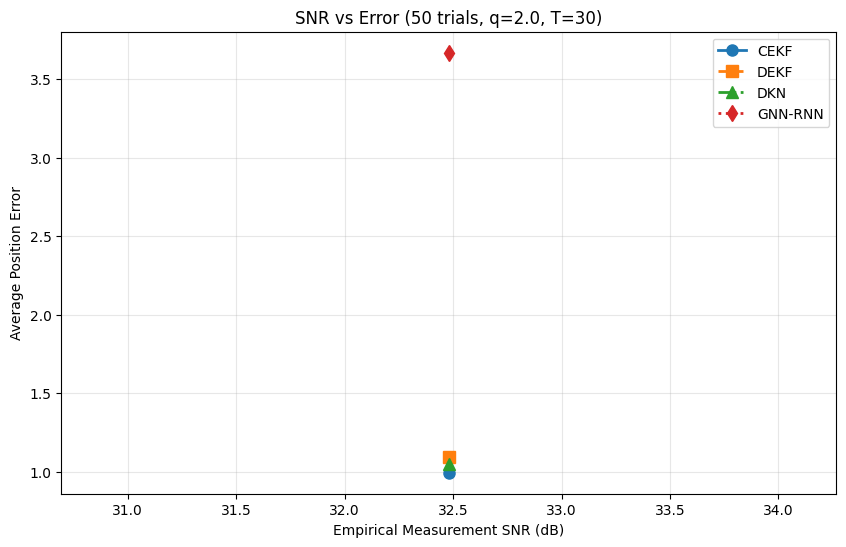

In [6]:
summary_plot_path = plot_dir / f"const_vel_scenario_summary_trials={num_trials}_T={num_time_steps}.png"
plt.figure(figsize=(10, 6))
plt.plot(results_df["measurement_noise"], results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
plt.plot(results_df["measurement_noise"], results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
plt.plot(results_df["measurement_noise"], results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
if "GNN-RNN" in results_df.columns and results_df["GNN-RNN"].notna().any():
    plt.plot(results_df["measurement_noise"], results_df["GNN-RNN"], "d:", linewidth=2, markersize=8, label="GNN-RNN")
plt.xlabel("Measurement Noise (r)")
plt.ylabel("Average Position Error")
plt.title(f"Constant Velocity Scenario Comparison ({num_trials} trials, q={process_noise_std}, T={num_time_steps}, learn_edge_kalman={config_val['learn_edge_kalman']})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved summary plot: {summary_plot_path}")
plt.show()

snr_summary_plot_path = plot_dir / f"const_vel_scenario_snr_vs_error_trials={num_trials}_T={num_time_steps}.png"
snr_results_df = results_df.sort_values("snr_db")
plt.figure(figsize=(10, 6))
plt.plot(snr_results_df["snr_db"], snr_results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
plt.plot(snr_results_df["snr_db"], snr_results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
plt.plot(snr_results_df["snr_db"], snr_results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
if "GNN-RNN" in snr_results_df.columns and snr_results_df["GNN-RNN"].notna().any():
    plt.plot(snr_results_df["snr_db"], snr_results_df["GNN-RNN"], "d:", linewidth=2, markersize=8, label="GNN-RNN")
plt.xlabel("Empirical Measurement SNR (dB)")
plt.ylabel("Average Position Error")
plt.title(f"SNR vs Error ({num_trials} trials, q={process_noise_std}, T={num_time_steps})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(snr_summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved SNR summary plot: {snr_summary_plot_path}")
plt.show()

## dt Mismatch Robustness

Sweep over `dt_mismatch` multipliers. Data is always generated with the **true** `time_delta`; CEKF, DEKF, and DKN run with an internal model that uses `time_delta × ratio`. The DKN checkpoint trained at each ratio is loaded. If a GNN-RNN checkpoint is present, the same checkpoint is reused for every ratio because the baseline has no explicit dynamics model.

In [7]:
if not config_val.get("use_dt_mismatch", False):
    raise RuntimeError("Set use_dt_mismatch=true in the experiment config to run this section.")

mismatch_save_root = REPO_ROOT / "models" / "kfir"  
mismatch_experiments = list_experiments(mismatch_save_root)
if not mismatch_experiments:
    raise RuntimeError(f"No experiment_* folders found under {mismatch_save_root}")

print("Available mismatch experiments:")
for i, exp in enumerate(mismatch_experiments, start=1):
    tag = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        desc = ecfg.get("description", "")
        desc_str = f' — "{desc}"' if desc else ""
        tag = f"  (train_T={ecfg.get('train_time_steps','?')}){desc_str}"
    print(f"  [{i}] {exp.name}{tag}")

MISMATCH_EXPERIMENT = 3  # ← set this, then run
R_MISMATCH_EVAL = 1.0    # ← noise level to evaluate (must match a trained checkpoint)

mismatch_experiment_dir = mismatch_experiments[MISMATCH_EXPERIMENT - 1]
mismatch_config = load_experiment_config(mismatch_experiment_dir)
dt_mismatch_values = mismatch_config.get("dt_mismatch_values", [1.0])
mismatch_plot_dir = mismatch_experiment_dir / "plots"
mismatch_plot_dir.mkdir(parents=True, exist_ok=True)

print(f"\nLoaded: {mismatch_experiment_dir.name}")
print(f"dt_mismatch_values: {dt_mismatch_values}")
print(f"Evaluating at r={R_MISMATCH_EVAL}")


RuntimeError: Set use_dt_mismatch=true in the experiment config to run this section.

ratio=0.5:   0%|          | 0/50 [00:00<?, ?it/s]/home/kfir-goldring/University/distributedKNET/utils/ConstantVelocityScenario.py:456: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trajectory_tensor = torch.tensor(trajectory, dtype=torch.float32)
ratio=1.5: 100%|██████████| 50/50 [00:02<00:00, 19.79it/s]


Saved: /home/kfir-goldring/University/distributedKNET/models/kfir/experiment_3/plots/mismatch_robustness_r=1.0_trials=50.png


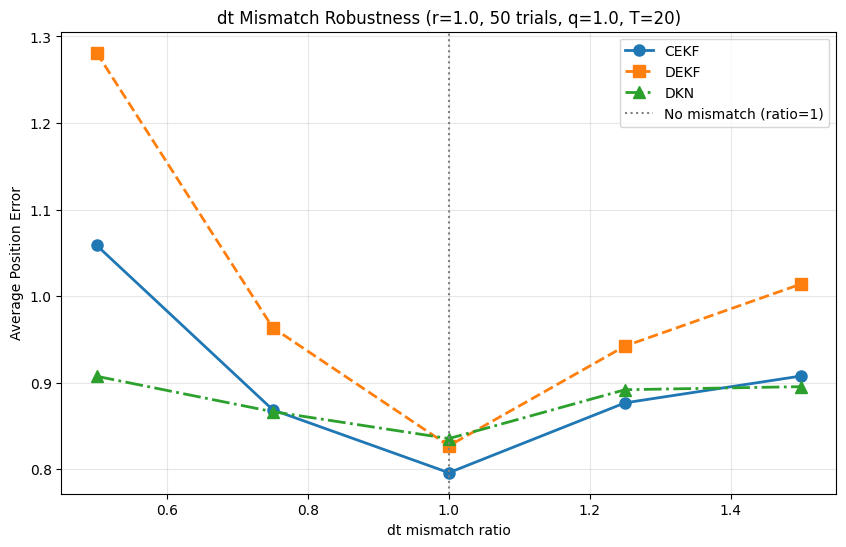

,dt_mismatch,CEKF,DEKF,DKN
0,0.50,1.058689,1.281214,0.907416
1,0.75,0.868675,0.963538,0.866487
2,1.00,0.795973,0.827081,0.835437
3,1.25,0.876705,0.942355,0.891859
4,1.50,0.907712,1.014036,0.895417


In [ ]:
mismatch_errors_cekf = []
mismatch_errors_dekf = []
mismatch_errors_dkn = []
mismatch_errors_gnn_rnn = []

r_array_mismatch = R_MISMATCH_EVAL * np.ones(num_nodes)
f_data = ConstantVelocityModel(time_delta)  # true dynamics - data always uses real dt
mismatch_gnn_rnn_process = None
mismatch_gnn_rnn_path = gnn_rnn_model_path(R_MISMATCH_EVAL, base_dir=mismatch_experiment_dir)
if mismatch_gnn_rnn_path.exists():
    mismatch_gnn_rnn_process = build_gnn_rnn_model(mismatch_config)
    mismatch_gnn_rnn_process.load_state_dict(torch.load(mismatch_gnn_rnn_path, map_location="cpu"))
    mismatch_gnn_rnn_process.eval()
else:
    print(f"No GNN-RNN checkpoint found at {mismatch_gnn_rnn_path}; omitting GNN-RNN from mismatch sweep.")

for ratio in dt_mismatch_values:
    f_model_r = ConstantVelocityModel(time_delta * ratio)  # assumed (wrong) model

    model_path = mismatch_experiment_dir / "DKN" / f"r={R_MISMATCH_EVAL}_dtx{ratio}.pth"
    kalman_process_m = GraphKalmanProcess(
        f_model_r,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=mismatch_config["hidden_dim"],
        lr=mismatch_config["learning_rate"],
        r_array=R_MISMATCH_EVAL,
        learn_edge_kalman=mismatch_config["learn_edge_kalman"],
        x0_scale=x_init,
    )
    kalman_process_m.load_state_dict(torch.load(model_path, map_location="cpu"))
    kalman_process_m.eval()

    trial_errors_cekf_m = []
    trial_errors_dekf_m = []
    trial_errors_dkn_m = []
    trial_errors_gnn_rnn_m = []

    for _ in tqdm(range(num_trials), desc=f"ratio={ratio}"):
        trajectory = generate_trajectory(f_data, x_init, num_time_steps, process_noise_std)
        measurements = generate_measurements(h_system, trajectory, R_MISMATCH_EVAL)

        x_hat_cekf_m = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )
        x_hat_dekf_m = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn_m = kalman_process_m(graph_data).squeeze().cpu().numpy().mean(axis=1)
        x_hat_gnn_rnn_m = predict_gnn_rnn(mismatch_gnn_rnn_process, graph_data, h_system) if mismatch_gnn_rnn_process is not None else None

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf_m[:, 0, 0]
        y_cekf = x_hat_cekf_m[:, 2, 0]
        trial_errors_cekf_m.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf_m[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf_m[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf_m.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn_m.append(np.sqrt((x_true - x_hat_dkn_m[:, 0]) ** 2 + (y_true - x_hat_dkn_m[:, 2]) ** 2).mean())
        if x_hat_gnn_rnn_m is not None:
            trial_errors_gnn_rnn_m.append(np.sqrt((x_true - x_hat_gnn_rnn_m[:, 0]) ** 2 + (y_true - x_hat_gnn_rnn_m[:, 2]) ** 2).mean())

    mismatch_errors_cekf.append(np.mean(trial_errors_cekf_m))
    mismatch_errors_dekf.append(np.mean(trial_errors_dekf_m))
    mismatch_errors_dkn.append(np.mean(trial_errors_dkn_m))
    mismatch_errors_gnn_rnn.append(np.mean(trial_errors_gnn_rnn_m) if trial_errors_gnn_rnn_m else np.nan)

mismatch_results_df = pd.DataFrame({
    "dt_mismatch": dt_mismatch_values,
    "CEKF": mismatch_errors_cekf,
    "DEKF": mismatch_errors_dekf,
    "DKN": mismatch_errors_dkn,
    "GNN-RNN": mismatch_errors_gnn_rnn,
})

mismatch_summary_path = mismatch_plot_dir / f"mismatch_robustness_r={R_MISMATCH_EVAL}_trials={num_trials}.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
if mismatch_results_df["GNN-RNN"].notna().any():
    ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["GNN-RNN"], "d:", linewidth=2, markersize=8, label="GNN-RNN")
ax.axvline(x=1.0, color="gray", linestyle=":", linewidth=1.5, label="No mismatch (ratio=1)")
ax.set_xlabel("dt mismatch ratio")
ax.set_ylabel("Average Position Error")
ax.set_title(f"dt Mismatch Robustness (r={R_MISMATCH_EVAL}, {num_trials} trials, q={process_noise_std}, T={num_time_steps})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(mismatch_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {mismatch_summary_path}")
plt.show()

mismatch_results_df

## Node-Count Generalization

Evaluate trained DKN and optional GNN-RNN checkpoints against fresh constant-velocity scenarios with different numbers of test nodes. Set `TEST_NUM_NODES_VALUES` below to choose the sweep; both neural models are node-count-agnostic as long as the sensor measurement types are rebuilt for each graph.


nodes=40: 100%|██████████| 50/50 [00:17<00:00,  2.81it/s]


Saved: /home/kfir-goldring/University/distributedKNET/models/kfir/experiment_3/plots/node_count_generalization_r=1.0_dtx1_trainN=10_trials=50.png


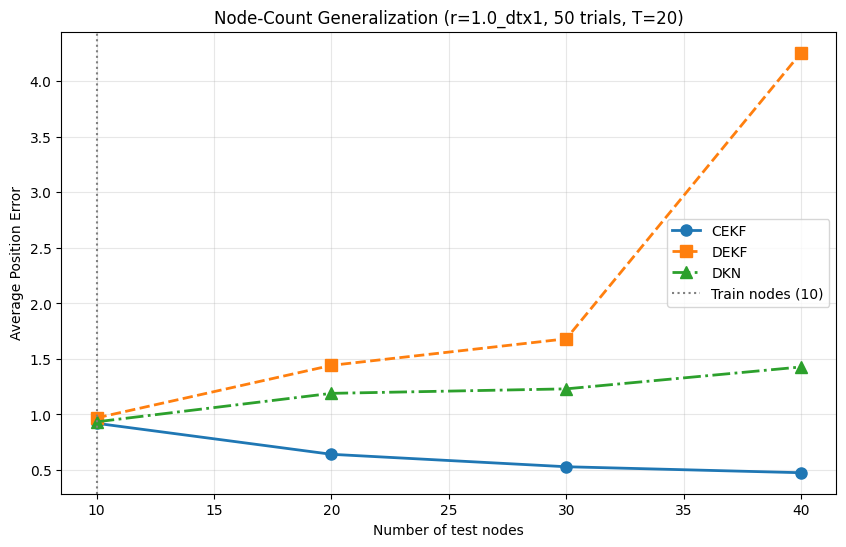

,test_num_nodes,CEKF,DEKF,DKN
0,10,0.920623,0.968964,0.933682
1,20,0.641400,1.442170,1.190216
2,30,0.529360,1.681364,1.230637
3,40,0.475465,4.257578,1.427937


In [ ]:
TEST_NUM_NODES_VALUES = [10, 20, 30, 40]  # ← node counts to evaluate against

train_num_nodes = num_nodes
NODE_COUNT_R_EVAL = measurement_noise_values[0]
NODE_COUNT_DKN_DT_RATIO = default_dkn_dt_ratio if use_dt_mismatch else None
node_count_run_name = dkn_run_name(NODE_COUNT_R_EVAL, NODE_COUNT_DKN_DT_RATIO)
node_count_model_path = dkn_model_path(NODE_COUNT_R_EVAL, NODE_COUNT_DKN_DT_RATIO)
#node_count_model_path ="/home/kfir-goldring/University/distributedKNET/models/kfir/experiment_3/DKN/r=1.0_dtx1.pth"
if not node_count_model_path.exists():
    raise FileNotFoundError(f"Missing DKN checkpoint for node-count sweep: {node_count_model_path}")

f_data_nodes = ConstantVelocityModel(time_delta)
f_model_nodes = ConstantVelocityModel(time_delta * float(NODE_COUNT_DKN_DT_RATIO)) if use_dt_mismatch else f_data_nodes

node_count_kalman_process = GraphKalmanProcess(
    f_model_nodes,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    # Scalar noise keeps the loaded DKN usable for any test graph size.
    r_array=NODE_COUNT_R_EVAL,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
node_count_kalman_process.load_state_dict(torch.load(node_count_model_path, map_location="cpu"))
node_count_kalman_process.eval()

node_count_gnn_rnn_process = None
node_count_gnn_rnn_path = gnn_rnn_model_path(NODE_COUNT_R_EVAL)
if node_count_gnn_rnn_path.exists():
    node_count_gnn_rnn_process = build_gnn_rnn_model(config_val)
    node_count_gnn_rnn_process.load_state_dict(torch.load(node_count_gnn_rnn_path, map_location="cpu"))
    node_count_gnn_rnn_process.eval()
else:
    print(f"No GNN-RNN checkpoint found at {node_count_gnn_rnn_path}; omitting GNN-RNN from node-count sweep.")

node_count_errors_cekf = []
node_count_errors_dekf = []
node_count_errors_dkn = []
node_count_errors_gnn_rnn = []

for test_num_nodes in TEST_NUM_NODES_VALUES:
    # Rebuild all graph-dependent objects for this test node count.
    test_node_positions = generate_node_positions(test_num_nodes, seed=config_val["graph_seed"])
    test_h_system = DistanceAngleObservation(test_node_positions)
    test_adjacency_matrix = create_distance_based_graph(
        test_node_positions,
        k_neighbors=config_val["k_neighbors"],
        seed=config_val["graph_seed"],
    )
    test_j_matrix = np.array(test_adjacency_matrix, dtype=float, copy=True)
    np.fill_diagonal(test_j_matrix, 1.0)
    test_r_array = NODE_COUNT_R_EVAL * np.ones(test_num_nodes)

    # Paired trials keep CEKF, DEKF, and DKN on identical measurements.
    paired_trials = []
    for _ in range(num_trials):
        traj = generate_trajectory(f_data_nodes, x_init, num_time_steps, process_noise_std)
        meas = generate_measurements(test_h_system, traj, NODE_COUNT_R_EVAL)
        paired_trials.append((traj, meas))

    trial_errors_cekf = []
    trial_errors_dekf = []
    trial_errors_dkn = []
    trial_errors_gnn_rnn = []

    for trajectory, measurements in tqdm(paired_trials, desc=f"nodes={test_num_nodes}"):
        x_hat_cekf_n = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_model_nodes,
            h_system=test_h_system,
            r_array=test_r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=test_num_nodes,
        )
        x_hat_dekf_n = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_nodes,
            h_system=test_h_system,
            r_array=test_r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=test_j_matrix,
            time_steps=num_time_steps,
            node_num=test_num_nodes,
        )

        graph_data = build_graph_data_for_dkn(test_adjacency_matrix, test_h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn_n = node_count_kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)
        x_hat_gnn_rnn_n = predict_gnn_rnn(node_count_gnn_rnn_process, graph_data, test_h_system) if node_count_gnn_rnn_process is not None else None

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf_n[:, 0, 0]
        y_cekf = x_hat_cekf_n[:, 2, 0]
        trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf_n[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf_n[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn_n[:, 0]) ** 2 + (y_true - x_hat_dkn_n[:, 2]) ** 2).mean())
        if x_hat_gnn_rnn_n is not None:
            trial_errors_gnn_rnn.append(np.sqrt((x_true - x_hat_gnn_rnn_n[:, 0]) ** 2 + (y_true - x_hat_gnn_rnn_n[:, 2]) ** 2).mean())

    node_count_errors_cekf.append(np.mean(trial_errors_cekf))
    node_count_errors_dekf.append(np.mean(trial_errors_dekf))
    node_count_errors_dkn.append(np.mean(trial_errors_dkn))
    node_count_errors_gnn_rnn.append(np.mean(trial_errors_gnn_rnn) if trial_errors_gnn_rnn else np.nan)

node_count_results_df = pd.DataFrame({
    "test_num_nodes": TEST_NUM_NODES_VALUES,
    "CEKF": node_count_errors_cekf,
    "DEKF": node_count_errors_dekf,
    "DKN": node_count_errors_dkn,
    "GNN-RNN": node_count_errors_gnn_rnn,
})

node_count_summary_path = plot_dir / f"node_count_generalization_{node_count_run_name}_trainN={train_num_nodes}_trials={num_trials}.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
if node_count_results_df["GNN-RNN"].notna().any():
    ax.plot(node_count_results_df["test_num_nodes"], node_count_results_df["GNN-RNN"], "d:", linewidth=2, markersize=8, label="GNN-RNN")
ax.axvline(x=train_num_nodes, color="gray", linestyle=":", linewidth=1.5, label=f"Train nodes ({train_num_nodes})")
ax.set_xlabel("Number of test nodes")
ax.set_ylabel("Average Position Error")
ax.set_title(f"Node-Count Generalization,fix Graph degree=5({node_count_run_name}, {num_trials} trials, T={num_time_steps})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(node_count_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {node_count_summary_path}")
plt.show()

node_count_results_df
